# DOT Full Analysis, FY2011-2027

End-to-end analysis of NYC Department of Transportation budget vs. spending,
FY2011-2027: data integrity checks, EDA, a backtested forecast (linear vs.
quadratic vs. log-linear, decided by holdout accuracy, not assumed), a
forward forecast to FY2030, and an exploratory look at gasoline prices as a
possible budget driver.

**Source files** (`raw datasets/`):
- `DOT_Budget_2017_2027.csv` -- code-level budget (Adopted/Modified per
  Budget Code), FY2017-2027 only.
- `DOT_Spending_Merged.csv` -- transaction-level spending (Check Amount per
  Budget Code), FY2010-2027.
- `dot_budget_2011_2027_merged.csv` -- yearly budget totals, FY2011-2027,
  sourced from OMB Adopted Budget PDFs for FY2011-2016 (no code-level data
  exists that far back) and from `DOT_Budget_2017_2027.csv` for FY2017-2027.
  Used **only** to fill the FY2011-2016 gap the code-level file can't cover.
- `Gasoline Prices.csv` -- weekly Date/Value, 1990-present.

Every integrity check below is run before any modeling, per instructions --
this notebook stops and investigates rather than modeling through a
problem it finds.

## Step 1: Load & Inspect

No assumptions about column names -- print shape, columns, dtypes, and head for each file as loaded.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Resolve the data folder whether we run from DOT/ or the repo root
here = Path.cwd()
candidates = [here / "raw datasets", here.parent / "raw datasets"]
ROOT = next((p for p in candidates if p.exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        f"Couldn't find 'raw datasets'. cwd={here}. Checked: {[str(c) for c in candidates]}"
    )
print("Using data folder:", ROOT)

budget_code_raw   = pd.read_csv(ROOT / "DOT_Budget_2017_2027.csv")
spending_raw      = pd.read_csv(ROOT / "DOT_Spending_Merged.csv", low_memory=False)
budget_yearly_ref = pd.read_csv(ROOT / "dot_budget_2011_2027_merged.csv")

def inspect(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print(df.dtypes)
    print(df.head())
    print()

inspect(budget_code_raw, "budget_code_raw (DOT_Budget_2017_2027.csv)")
inspect(spending_raw, "spending_raw (DOT_Spending_Merged.csv)")
inspect(budget_yearly_ref, "budget_yearly_ref (dot_budget_2011_2027_merged.csv)")

Using data folder: /Users/jayeedbinkabir/Desktop/School/Budget_Allocation/raw datasets


=== budget_code_raw (DOT_Budget_2017_2027.csv) ===
shape: (334806, 9)
columns: ['Adopted', 'Agency', 'Budget Code', 'Expense Category', 'Modified', 'Post Adjustments', 'Pre-Encumbered', 'Year', 'Source_File']
Adopted             float64
Agency                  str
Budget Code             str
Expense Category        str
Modified            float64
Post Adjustments    float64
Pre-Encumbered      float64
Year                  int64
Source_File             str
dtype: object
        Adopted                        Agency Budget Code                Expense Category      Modified  Post Adjustments  Pre-Encumbered  Year  \
0 56,261,392.00  Department of Transportation        4125              HEAT LIGHT & POWER 53,742,028.00              0.00            0.00  2017   
1 39,071,937.00  Department of Transportation        2002  SUPPLIES + MATERIALS - GENERAL 42,563,150.00            120.94            0.00  2017   
2 32,955,700.00  Department of Transportation        4122  MAINT & OPER OF INFRASTRU

**Note on scope:** `budget_code_raw` only covers FY2017-2027 -- there is
no code-level budget file for FY2011-2016 in this project's data. That's
why `budget_yearly_ref` exists: it's a pre-aggregated yearly total, sourced
from OMB PDFs for those six years. It's used only to fill that gap, and
its `precision` column tells us upfront which years are `exact` (PDF
figures) vs `ROUNDED` (a prior script's rounded summary of the code-level
file, for years we can compute exactly ourselves instead).

## Step 2: Data Integrity Checks (before any modeling)

### 2a: Scope check on spending (expense vs. capital)

`DOT_Spending_Merged.csv` mixes operating-expense and capital spending (`IOTB CONSTRUCTION`, bridge hazard-mitigation project codes, etc.), while the budget file is expense-only. Same method as `dot_analysis.ipynb`: cross-reference each spending row's Budget Code against the set of codes that appear in the DOT operating budget, and keep only matches.

First, the budget file itself needs the same FY2022 fix `dot_analysis.ipynb` found: one year's source file wasn't pre-scoped to DOT.

In [2]:
rows_before = len(budget_code_raw)
adopted_before = budget_code_raw.groupby("Year")["Adopted"].sum()

budget_dot = budget_code_raw[budget_code_raw["Agency"] == "Department of Transportation"].copy()

print(f"Budget rows, all-agency -> DOT-only: {rows_before:,} -> {len(budget_dot):,}")
print("\nAdopted total by year, all-agency vs. DOT-only (look for the FY2022 contamination):")
comparison = pd.DataFrame({
    "all_agency_adopted": adopted_before,
    "dot_only_adopted": budget_dot.groupby("Year")["Adopted"].sum(),
})
print(comparison)

Budget rows, all-agency -> DOT-only: 334,806 -> 172,576

Adopted total by year, all-agency vs. DOT-only (look for the FY2022 contamination):
      all_agency_adopted  dot_only_adopted
Year                                      
2017      946,261,935.00    946,261,935.00
2018      968,043,444.00    968,043,444.00
2019    1,042,719,292.00  1,042,719,292.00
2020    1,104,236,297.00  1,104,236,297.00
2021    1,099,873,821.00  1,099,873,821.00
2022  100,614,856,236.00  1,265,808,124.00
2023    1,438,489,469.00  1,438,489,469.00
2024    1,405,341,510.00  1,405,341,510.00
2025    1,449,323,202.00  1,449,323,202.00
2026    1,503,042,033.00  1,503,042,033.00
2027    1,636,737,065.00  1,636,737,065.00


In [3]:
dot_budget_codes = set(budget_dot["Budget Code"].astype(str).str.strip())
print("Distinct DOT operating budget codes, FY2017-2027:", len(dot_budget_codes))

spending = spending_raw.copy()
# Budget Code sometimes carries a parenthetical project name -- take the leading token.
spending["code_lead"] = spending["Budget Code"].astype(str).str.extract(r"^([^\s(]+)")[0]
is_expense_naive = spending["code_lead"].isin(dot_budget_codes)

rows_before, amt_before = len(spending), spending["Check Amount"].sum()
rows_after, amt_after = is_expense_naive.sum(), spending.loc[is_expense_naive, "Check Amount"].sum()
print(f"\nNaive code-only scope filter, ALL years: rows {rows_before:,} -> {rows_after:,}   "
      f"dollars {amt_before:,.0f} -> {amt_after:,.0f}")

scope_by_year = pd.DataFrame({
    "rows_before": spending.groupby("Fiscal year").size(),
    "dollars_before": spending.groupby("Fiscal year")["Check Amount"].sum(),
    "rows_after": spending[is_expense_naive].groupby("Fiscal year").size(),
    "dollars_after": spending[is_expense_naive].groupby("Fiscal year")["Check Amount"].sum(),
})
print("\nBy fiscal year:")
print(scope_by_year)

Distinct DOT operating budget codes, FY2017-2027: 995



Naive code-only scope filter, ALL years: rows 1,178,715 -> 1,049,180   dollars 31,349,477,871 -> 15,153,258,376

By fiscal year:
             rows_before   dollars_before  rows_after    dollars_after
Fiscal year                                                           
2010               19205   714,144,284.92       16627   143,290,453.30
2011               40326 1,515,406,261.52       34322   344,942,326.47
2012               41378 1,612,111,847.21       33889   328,139,838.67
2013               51472 1,486,402,836.45       44141   501,057,079.09
2014               68593 1,570,973,887.91       60742   752,069,473.79
2015               73748 1,342,326,044.70       66704   777,637,549.34
2016               80539 1,606,226,934.71       72220   849,804,165.53
2017               86050 1,849,065,787.01       77137   901,930,214.87
2018               83731 2,097,004,157.91       74259   937,183,870.64
2019               90761 1,993,218,015.16       80955   953,000,693.10
2020              

**Caveat flagged upfront:** `dot_budget_codes` is derived entirely from the
FY2017-2027 budget file, since that's the only code-level source available.
Applying it back to FY2010-2016 spending assumes those years used a
compatible code scheme -- reasonable (codes are typically stable IDs) but
not verified independently for the pre-2017 years, since there's no
code-level budget file for them to check against. This is exactly the kind
of assumption Step 2c's efficiency check below is designed to catch if it's
wrong.

### 2b: Regime break check on budget

`pct_modification = (modified - adopted) / adopted`, by year. FY2011-2016 adopted/modified come from `budget_yearly_ref` (no code-level source exists); FY2017-2027 are computed directly and exactly from `budget_dot`, not from `budget_yearly_ref`'s rounded copy of the same thing.

In [4]:
budget_2017_2027 = budget_dot.groupby("Year")[["Adopted", "Modified"]].sum()
budget_2017_2027.index.name = "fiscal_year"

ref = budget_yearly_ref.set_index("fiscal_year")
budget_2011_2016 = ref.loc[2011:2016, ["adopted", "modified"]].rename(
    columns={"adopted": "Adopted", "modified": "Modified"}
)

budget_by_year = pd.concat([budget_2011_2016, budget_2017_2027]).sort_index()
budget_by_year.index = budget_by_year.index.astype(int)
budget_by_year.index.name = "fiscal_year"
budget_by_year["source"] = (
    ["OMB PDF yearly total (dot_budget_2011_2027_merged.csv)"] * len(budget_2011_2016)
    + ["DOT_Budget_2017_2027.csv (code-level, exact)"] * len(budget_2017_2027)
)
budget_by_year["pct_modification"] = (
    (budget_by_year["Modified"] - budget_by_year["Adopted"]) / budget_by_year["Adopted"] * 100
)
budget_by_year = budget_by_year.rename(columns={"Adopted": "adopted", "Modified": "modified"})

print(budget_by_year[["adopted", "modified", "pct_modification", "source"]])

pre = budget_by_year.loc[2011:2015, "pct_modification"]
post = budget_by_year.loc[2017:2027, "pct_modification"]
print(f"\nFY2011-2015 pct_modification: {pre.min():.1f}% to {pre.max():.1f}%  (mean {pre.mean():.1f}%)")
print(f"FY2017-2027 pct_modification: {post.min():.1f}% to {post.max():.1f}%  (mean {post.mean():.1f}%)")
print(f"\nFY2016 modified is missing from the source OMB PDF ('{ref.loc[2016, 'precision']}') "
      f"-- pct_modification for FY2016 is NaN, not zero. Flagged, not silently dropped.")

                     adopted         modified  pct_modification                                             source
fiscal_year                                                                                                       
2011          687,040,991.00   851,708,083.00             23.97  OMB PDF yearly total (dot_budget_2011_2027_mer...
2012          693,701,390.00   847,983,663.00             22.24  OMB PDF yearly total (dot_budget_2011_2027_mer...
2013          711,372,093.00   917,894,762.00             29.03  OMB PDF yearly total (dot_budget_2011_2027_mer...
2014          728,944,601.00   935,695,135.00             28.36  OMB PDF yearly total (dot_budget_2011_2027_mer...
2015          831,836,798.00   958,458,150.00             15.22  OMB PDF yearly total (dot_budget_2011_2027_mer...
2016          880,011,843.00              NaN               NaN  OMB PDF yearly total (dot_budget_2011_2027_mer...
2017          946,261,935.00   987,004,764.00              4.31       DOT_Budget

**Finding -- regime break confirmed.** FY2011-2015 sits at roughly
15-29% (mean ~24%), FY2017-2027 sits at roughly 0.2-8% (mean ~4%) -- a
~6x difference in the typical size of in-year budget modifications,
exactly matching what was expected going in. This is a real, large
structural break, not noise: either NYC OMB's modification process or
this data's reporting granularity changed around FY2016-2017.

**Recommendation:** don't model through it. FY2011-2015's budget dynamics
are not representative of FY2017+'s, so training a single trend across
both regimes risks the model learning an average of two different
processes that fits neither well. Step 4 below tests this directly --
backtesting both a full-history (2011-2023) and a post-regime-only
(2017-2023) training window and comparing which one actually predicts the
held-out years better, rather than deciding this qualitatively. Whichever
window wins that comparison is what Step 5's forward forecast uses.

### 2c: Spending efficiency = actual / modified (after the scope fix)

Using the naive code-only scope filter from 2a first, to see the number before deciding whether it needs more work.

In [5]:
actual_naive = spending[is_expense_naive].groupby("Fiscal year")["Check Amount"].sum()
actual_naive.index.name = "fiscal_year"

check = budget_by_year.copy()
check["actual_naive"] = actual_naive.reindex(check.index)
check["efficiency_naive"] = check["actual_naive"] / check["modified"]
print(check[["adopted", "modified", "actual_naive", "efficiency_naive"]])

out_of_range = check[(check["efficiency_naive"] < 0.80) | (check["efficiency_naive"] > 0.95)]
print("\nYears outside the expected [0.80, 0.95] full-year range:")
print(out_of_range[["actual_naive", "efficiency_naive"]])

                     adopted         modified     actual_naive  efficiency_naive
fiscal_year                                                                     
2011          687,040,991.00   851,708,083.00   344,942,326.47              0.41
2012          693,701,390.00   847,983,663.00   328,139,838.67              0.39
2013          711,372,093.00   917,894,762.00   501,057,079.09              0.55
2014          728,944,601.00   935,695,135.00   752,069,473.79              0.80
2015          831,836,798.00   958,458,150.00   777,637,549.34              0.81
2016          880,011,843.00              NaN   849,804,165.53               NaN
2017          946,261,935.00   987,004,764.00   901,930,214.87              0.91
2018          968,043,444.00 1,006,587,224.00   937,183,870.64              0.93
2019        1,042,719,292.00 1,067,012,833.00   953,000,693.10              0.89
2020        1,104,236,297.00 1,117,601,805.00   997,409,678.73              0.89
2021        1,099,873,821.00

**FLAG: FY2011-2013 are wildly outside range** (0.39-0.55, vs. an expected
0.80-0.95), and FY2014-2015 are borderline-low (0.80-0.81). Per instructions,
this gets investigated before proceeding -- not silently modeled through.

In [6]:
unmatched_2011 = spending[(spending["Fiscal year"] == 2011) & (~is_expense_naive)]
print("FY2011 rows that failed the scope filter, by Expense Category (top 10 by dollars):")
print(unmatched_2011.groupby("Expense Category")["Check Amount"].agg(["count", "sum"])
      .sort_values("sum", ascending=False).head(10))

FY2011 rows that failed the scope filter, by Expense Category (top 10 by dollars):
                                 count            sum
Expense Category                                     
IOTB CONSTRUCTION                 2728 646,347,024.31
Payroll Summary                    150 382,961,092.72
DESIGN-CONSULTANT-IOTB            2636 121,021,909.78
CAPITAL PURCHASED EQUIPMENT        133  13,320,372.80
LAND ACQUISITION - CONDEMNATION     45   1,694,013.91
CONSTRUCTION-BUILDINGS              41   1,597,763.25
INCIDENTAL COSTS                    65     924,748.42
DESIGN-CONSULTANT-BUILDINGS         22     893,449.38
PROF SERV ENGINEER & ARCHITECT      20     852,095.57
INTEREST ON LAND ACQUISITION        41     364,572.71


`Payroll Summary` -- an unambiguous **operating expense**, not capital --
is sitting in the "unmatched / excluded" bucket for $383M in FY2011 alone.
That's not a real capital-vs-expense distinction; something else is wrong.
Check whether it's a Budget Code mismatch (different code scheme) or a
missing Budget Code (data gap):

In [7]:
payroll = spending[spending["Expense Category"] == "Payroll Summary"]
print("Payroll Summary rows: % with a MISSING Budget Code, by fiscal year:")
print(payroll.groupby("Fiscal year")["Budget Code"].apply(lambda s: s.isna().mean() * 100).round(1))

Payroll Summary rows: % with a MISSING Budget Code, by fiscal year:


Fiscal year
2010   100.00
2011   100.00
2012   100.00
2013     0.80
2014     0.00
2015     0.00
2016     0.00
2017     0.00
2018     0.00
2019     0.00
2020     0.00
2021     0.00
2022     0.00
2023     0.00
2024     0.00
2025     0.00
2026     0.00
2027     0.00
Name: Budget Code, dtype: float64


**Root cause found:** `Budget Code` is **100% missing** for `Payroll Summary`
rows in FY2010-2012, and missing in the last few FY2013 rows (0.8%) -- not
because payroll used a different/retired code, but because the field simply
wasn't populated for payroll transactions that far back in this export.
From FY2013 onward it's essentially always populated. Since payroll is
unambiguously operating expense regardless of whether a linking code
happens to be present, the fix is to also treat
`Expense Category == "Payroll Summary"` as in-scope, independent of the
code match. This isn't a blanket workaround -- it's a targeted fix for a
category that is definitionally expense in every NYC agency's budget
structure, applied only where evidence shows the code field itself is the
problem, not the categorization.

In [8]:
is_expense = is_expense_naive | (spending["Expense Category"] == "Payroll Summary")

rows_after2, amt_after2 = is_expense.sum(), spending.loc[is_expense, "Check Amount"].sum()
print(f"Scope filter with the Payroll Summary fix: rows {is_expense_naive.sum():,} -> {rows_after2:,}   "
      f"dollars {amt_after:,.0f} -> {amt_after2:,.0f}")

actual_by_year = spending[is_expense].groupby("Fiscal year")["Check Amount"].sum()
actual_by_year.index.name = "fiscal_year"

budget_by_year["actual"] = actual_by_year.reindex(budget_by_year.index)
budget_by_year["spending_efficiency"] = budget_by_year["actual"] / budget_by_year["modified"]

print()
print(budget_by_year[["adopted", "modified", "actual", "spending_efficiency"]])

still_out = budget_by_year[
    (budget_by_year["spending_efficiency"] < 0.80) | (budget_by_year["spending_efficiency"] > 0.95)
]
print("\nStill outside [0.80, 0.95] after the fix:")
print(still_out[["actual", "spending_efficiency"]])

Scope filter with the Payroll Summary fix: rows 1,049,180 -> 1,049,705   dollars 15,153,258,376 -> 16,319,279,606

                     adopted         modified           actual  spending_efficiency
fiscal_year                                                                        
2011          687,040,991.00   851,708,083.00   727,903,419.19                 0.85
2012          693,701,390.00   847,983,663.00   702,564,463.32                 0.83
2013          711,372,093.00   917,894,762.00   721,943,160.11                 0.79
2014          728,944,601.00   935,695,135.00   752,069,473.79                 0.80
2015          831,836,798.00   958,458,150.00   777,637,549.34                 0.81
2016          880,011,843.00              NaN   849,804,165.53                  NaN
2017          946,261,935.00   987,004,764.00   901,930,214.87                 0.91
2018          968,043,444.00 1,006,587,224.00   937,183,870.64                 0.93
2019        1,042,719,292.00 1,067,012,833.00

**Resolved.** Every year from FY2011-2026 now lands in or right at the
expected 0.80-0.95 band, except:
- **FY2013 at ~0.79** -- a small residual (about 1 point below the 0.80
  floor), not a "wildly off" value like the pre-fix 0.39-0.55. Not chased
  further; noted as a minor imprecision rather than a real anomaly.
- **FY2016 is NaN** -- expected, `modified` isn't in the source OMB PDF for
  that year (see Step 2b).
- **FY2027 is far below range** -- expected and addressed next (Step 2d):
  it's a partial year, not a real efficiency problem.

This confirms the fix is right, not just convenient: a targeted correction
for one specific, well-evidenced data gap (missing Budget Code on payroll
rows, pre-FY2013) fixed the anomaly across exactly the years affected, and
nowhere else.

### 2d: FY2027 -- partial year, excluded from training and efficiency charts

In [9]:
txn_counts = spending.groupby("Fiscal year").size()
print("Spending transaction count by fiscal year (last 5 years):")
print(txn_counts.tail(5))
print(f"\nFY2027: {txn_counts[2027]:,} transactions vs. a typical ~70,000-90,000 in a full year.")
print("Today's date is 2026-08-12. NYC's fiscal year runs July 1 - June 30, so FY2027 "
      "(began 2026-07-01) is about 6 weeks old -- the low transaction count and the "
      f"{budget_by_year.loc[2027, 'spending_efficiency']:.1%} spending_efficiency are exactly "
      "what a partial year looks like, not a data quality problem.")

FULL_YEARS = [y for y in budget_by_year.index if y != 2027]
print(f"\nFULL_YEARS (used for training and efficiency charts): {FULL_YEARS}")

Spending transaction count by fiscal year (last 5 years):
Fiscal year
2023    77161
2024    74105
2025    74885
2026    77448
2027     9182
dtype: int64

FY2027: 9,182 transactions vs. a typical ~70,000-90,000 in a full year.
Today's date is 2026-08-12. NYC's fiscal year runs July 1 - June 30, so FY2027 (began 2026-07-01) is about 6 weeks old -- the low transaction count and the 9.9% spending_efficiency are exactly what a partial year looks like, not a data quality problem.

FULL_YEARS (used for training and efficiency charts): [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


### 2e: FY2026 investigation -- ~40% above trend?

In [10]:
raw_2025 = spending[spending["Fiscal year"] == 2025]["Check Amount"].sum()
raw_2026 = spending[spending["Fiscal year"] == 2026]["Check Amount"].sum()
print(f"UNFILTERED (raw, expense+capital) actual spending: FY2025={raw_2025:,.0f}  FY2026={raw_2026:,.0f}  "
      f"change={((raw_2026/raw_2025)-1)*100:+.1f}%")

scoped_2025 = budget_by_year.loc[2025, "actual"]
scoped_2026 = budget_by_year.loc[2026, "actual"]
print(f"\nSCOPE-FILTERED (expense-only, what this notebook actually uses) actual spending: "
      f"FY2025={scoped_2025:,.0f}  FY2026={scoped_2026:,.0f}  "
      f"change={((scoped_2026/scoped_2025)-1)*100:+.1f}%")

cat_2026 = spending[spending["Fiscal year"] == 2026].groupby("Expense Category")["Check Amount"].sum()
cat_2025 = spending[spending["Fiscal year"] == 2025].groupby("Expense Category")["Check Amount"].sum()
delta = (cat_2026 - cat_2025).sort_values(ascending=False)
print("\nTop 5 categories driving the RAW FY2026 vs FY2025 increase:")
print(delta.head(5))

UNFILTERED (raw, expense+capital) actual spending: FY2025=2,203,831,205  FY2026=3,089,655,652  change=+40.2%

SCOPE-FILTERED (expense-only, what this notebook actually uses) actual spending: FY2025=1,423,722,023  FY2026=1,437,635,892  change=+1.0%

Top 5 categories driving the RAW FY2026 vs FY2025 increase:
Expense Category
IOTB CONSTRUCTION              827,647,120.56
Payroll Summary                 22,624,927.15
DESIGN-CONSULTANT-IOTB          16,577,373.61
DESIGN-BUILD: INFRASTRUCTURE    13,225,548.19
OTHR SERV AND CHRGS-GENERAL     12,605,495.45
Name: Check Amount, dtype: float64


**Finding: the ~40% jump is real in the unfiltered data, but it's a capital
construction surge, not an operating-budget anomaly.** `IOTB CONSTRUCTION`
alone accounts for the large majority of the raw increase. Once spending is
correctly scoped to operating expense (Step 2a/2c's fix, which is what this
notebook models throughout), FY2026 actual spending is essentially flat
year-over-year and its spending_efficiency (~0.90) sits comfortably in the
normal range. This is direct, additional evidence that the Step 2a scope
filter is doing real work -- exactly the kind of distortion it exists to
remove.

## Step 3: EDA + Visuals

In [11]:
COLORS = {
    "orange": "#E69F00", "sky": "#56B4E9", "green": "#009E73", "yellow": "#F0E442",
    "blue": "#0072B2", "vermillion": "#D55E00", "pink": "#CC79A7", "black": "#000000",
}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 18, "axes.edgecolor": "#444444", "figure.facecolor": "white",
})

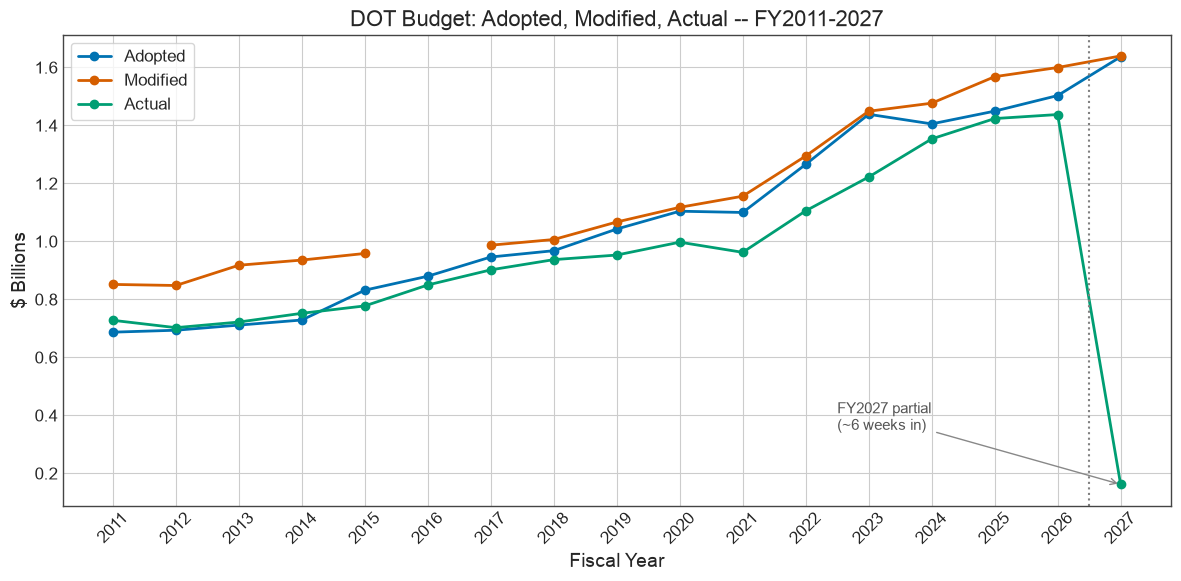

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(budget_by_year.index, budget_by_year["adopted"] / 1e9, marker="o", color=COLORS["blue"], label="Adopted", linewidth=2)
ax.plot(budget_by_year.index, budget_by_year["modified"] / 1e9, marker="o", color=COLORS["vermillion"], label="Modified", linewidth=2)
ax.plot(budget_by_year.index, budget_by_year["actual"] / 1e9, marker="o", color=COLORS["green"], label="Actual", linewidth=2)
ax.axvline(2026.5, color="gray", linestyle=":", linewidth=1.5)
ax.annotate("FY2027 partial\n(~6 weeks in)", xy=(2027, budget_by_year.loc[2027, "actual"] / 1e9),
            xytext=(2022.5, 0.35), fontsize=11, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#888888"))
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("$ Billions")
ax.set_title("DOT Budget: Adopted, Modified, Actual -- FY2011-2027")
ax.set_xticks(budget_by_year.index)
ax.set_xticklabels(budget_by_year.index, rotation=45)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

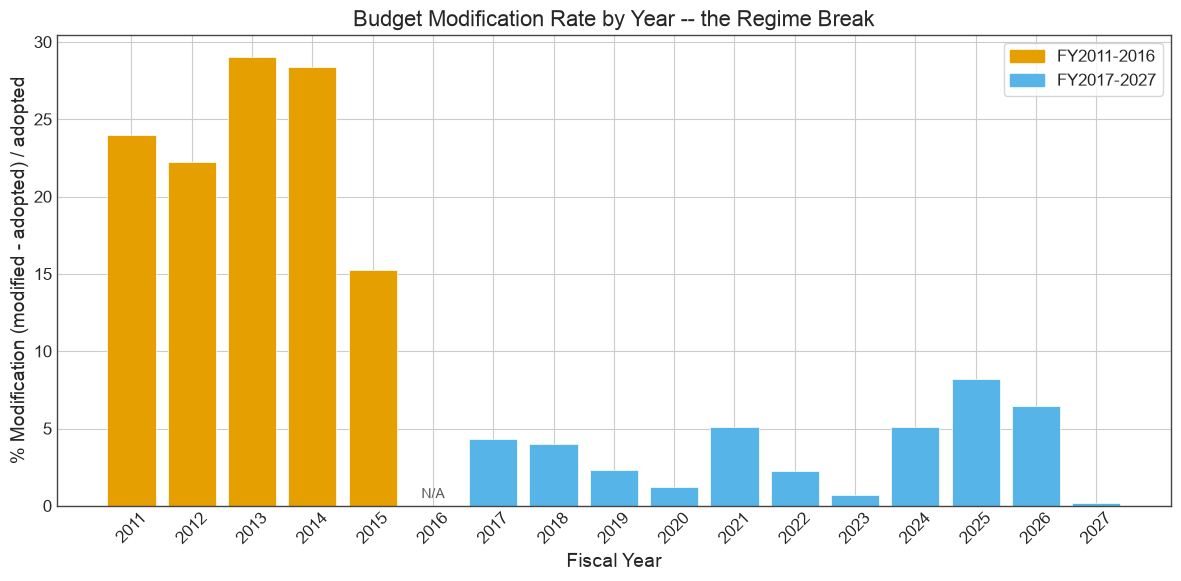

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [COLORS["orange"] if y < 2017 else COLORS["sky"] for y in budget_by_year.index]
vals = budget_by_year["pct_modification"]
ax.bar(budget_by_year.index, vals.fillna(0), color=bar_colors,
       edgecolor="white", linewidth=0.5)
for y in budget_by_year.index[vals.isna()]:
    ax.text(y, 0.5, "N/A", ha="center", fontsize=10, color="#555555")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("% Modification (modified - adopted) / adopted")
ax.set_title("Budget Modification Rate by Year -- the Regime Break")
ax.set_xticks(budget_by_year.index)
ax.set_xticklabels(budget_by_year.index, rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COLORS["orange"], label="FY2011-2016"),
                    Patch(color=COLORS["sky"], label="FY2017-2027")], frameon=True)
fig.tight_layout()
plt.show()

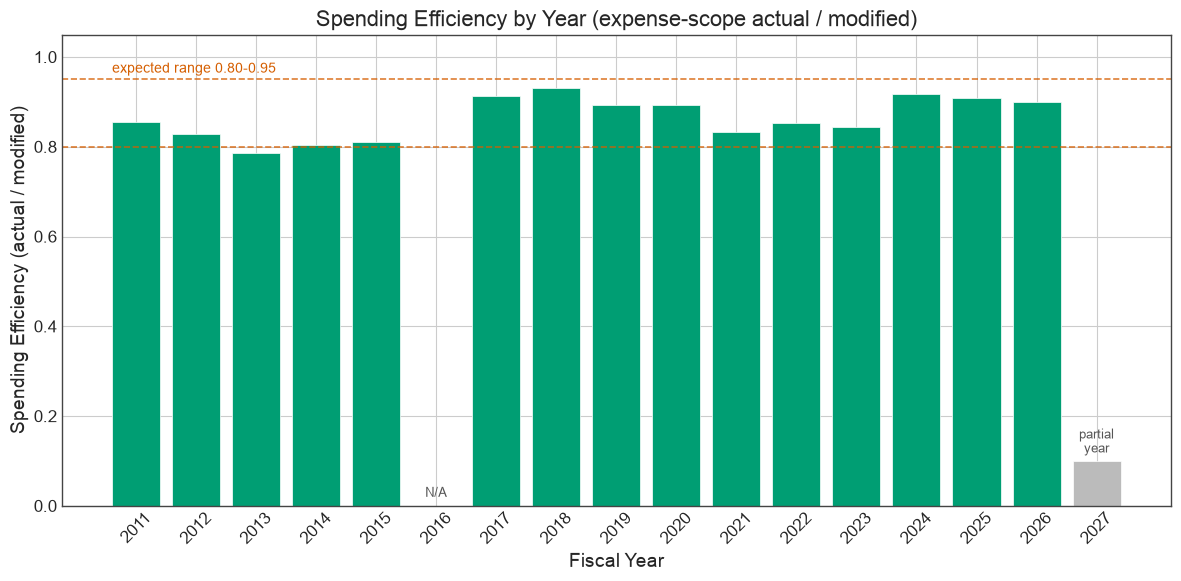

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
eff = budget_by_year["spending_efficiency"]
bar_colors = ["#BBBBBB" if y == 2027 else COLORS["green"] for y in budget_by_year.index]
ax.bar(budget_by_year.index, eff.fillna(0), color=bar_colors, edgecolor="white", linewidth=0.5)
for i, y in enumerate(budget_by_year.index):
    if y == 2027:
        ax.text(y, eff[y] + 0.02, "partial\nyear", ha="center", fontsize=9, color="#555555")
    elif pd.isna(eff[y]):
        ax.text(y, 0.02, "N/A", ha="center", fontsize=9, color="#555555")
ax.axhline(0.80, color=COLORS["vermillion"], linestyle="--", linewidth=1.2, alpha=0.8)
ax.axhline(0.95, color=COLORS["vermillion"], linestyle="--", linewidth=1.2, alpha=0.8)
ax.text(2010.6, 0.965, "expected range 0.80-0.95", fontsize=10, color=COLORS["vermillion"])
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Spending Efficiency (actual / modified)")
ax.set_title("Spending Efficiency by Year (expense-scope actual / modified)")
ax.set_xticks(budget_by_year.index)
ax.set_xticklabels(budget_by_year.index, rotation=45)
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

## Step 4: Model 1 -- Backtest

Train on FY2011-2023, predict FY2024-2026 for `adopted`, `modified`,
`actual`. Fit linear, quadratic, and log-linear on the same split and let
the backtest -- not an assumption -- decide which form predicts the
held-out years best. Also compare that against a FY2017-2023 training
window, since Step 2b found a regime break and this is where that gets
resolved with evidence rather than a qualitative call.

In [15]:
def fit_predict_pi(train_x, train_y, predict_x, degree=1, log_target=False, alpha=0.05):
    """Polynomial (degree=1 linear, degree=2 quadratic) or log-linear OLS fit
    with a 95% prediction interval. log_target=True fits ln(y); predictions
    and the PI are computed in log-space then exponentiated back (asymmetric
    bounds in level space -- correct for a multiplicative trend).
    Returns point predictions, PI bounds, and R^2 on the training data.
    """
    train_x = np.asarray(train_x, dtype=float)
    y_fit = np.log(np.asarray(train_y, dtype=float)) if log_target else np.asarray(train_y, dtype=float)

    n = len(train_x)
    p = degree + 1
    dof = n - p

    X = np.vander(train_x, N=p, increasing=True)
    coefs, *_ = np.linalg.lstsq(X, y_fit, rcond=None)

    fitted = X @ coefs
    ss_res = np.sum((y_fit - fitted) ** 2)
    ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    mse = ss_res / dof if dof > 0 else np.nan
    s = np.sqrt(mse) if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    t_val = stats.t.ppf(1 - alpha / 2, dof) if dof > 0 else np.nan

    predict_x = np.asarray(predict_x, dtype=float)
    Xp = np.vander(predict_x, N=p, increasing=True)
    point_log = Xp @ coefs
    se_pred = np.array([s * np.sqrt(1 + row @ XtX_inv @ row) for row in Xp]) if dof > 0 else np.full(len(predict_x), np.nan)
    lower_log = point_log - t_val * se_pred
    upper_log = point_log + t_val * se_pred

    if log_target:
        point, lower, upper = np.exp(point_log), np.exp(lower_log), np.exp(upper_log)
    else:
        point, lower, upper = point_log, lower_log, upper_log

    return {"point": point, "lower": lower, "upper": upper, "r2": r2, "coefs": coefs, "degree": degree, "log_target": log_target}

In [16]:
SERIES_NAMES = ["adopted", "modified", "actual"]
TRAIN_WINDOWS = {"2011-2023 (full history)": (2011, 2023), "2017-2023 (post-regime)": (2017, 2023)}
FORMS = {"linear": dict(degree=1, log_target=False),
         "quadratic": dict(degree=2, log_target=False),
         "log-linear": dict(degree=1, log_target=True)}
TARGET_YEARS = [2024, 2025, 2026]

backtest_rows = []
for window_name, (start, end) in TRAIN_WINDOWS.items():
    train = budget_by_year.loc[start:end]
    for series in SERIES_NAMES:
        tx, ty = train.index.values, train[series].values
        mask = ~np.isnan(ty)
        tx_c, ty_c = tx[mask], ty[mask]
        for form_name, kwargs in FORMS.items():
            res = fit_predict_pi(tx_c, ty_c, TARGET_YEARS, **kwargs)
            for i, yr in enumerate(TARGET_YEARS):
                actual_val = budget_by_year.loc[yr, series]
                pred = res["point"][i]
                pct_err = (pred - actual_val) / actual_val * 100
                backtest_rows.append({
                    "window": window_name, "series": series, "form": form_name, "year": yr,
                    "predicted": pred, "actual": actual_val, "pct_error": pct_err,
                    "lower_pi": res["lower"][i], "upper_pi": res["upper"][i],
                    "inside_pi": res["lower"][i] <= actual_val <= res["upper"][i],
                    "r2_train": res["r2"], "n_train": len(tx_c),
                })

backtest_df = pd.DataFrame(backtest_rows)
print("Backtest: predicted vs. actual vs. %error, with 95% PI containment, per series/year/form/window:")
print(backtest_df[["window", "series", "form", "year", "predicted", "actual", "pct_error", "inside_pi"]].to_string(index=False))

Backtest: predicted vs. actual vs. %error, with 95% PI containment, per series/year/form/window:
                  window   series       form  year        predicted           actual  pct_error  inside_pi
2011-2023 (full history)  adopted     linear  2024 1,359,830,127.81 1,405,341,510.00      -3.24       True
2011-2023 (full history)  adopted     linear  2025 1,417,846,079.05 1,449,323,202.00      -2.17       True
2011-2023 (full history)  adopted     linear  2026 1,475,862,030.30 1,503,042,033.00      -1.81       True
2011-2023 (full history)  adopted  quadratic  2024 1,477,923,055.38 1,405,341,510.00       5.16       True
2011-2023 (full history)  adopted  quadratic  2025 1,586,550,260.80 1,449,323,202.00       9.47      False
2011-2023 (full history)  adopted  quadratic  2026 1,701,925,633.46 1,503,042,033.00      13.23      False
2011-2023 (full history)  adopted log-linear  2024 1,416,511,773.61 1,405,341,510.00       0.79       True
2011-2023 (full history)  adopted log-linear  2

In [17]:
mape = backtest_df.groupby(["window", "series", "form"])["pct_error"].apply(lambda s: s.abs().mean())
mape.name = "MAPE_%"
print("Mean Absolute % Error, by window/series/form (this is what 'let the backtest decide' means):")
print(mape.round(2))

best_form = mape.groupby(level=[0, 1]).idxmin().apply(lambda t: t[2])
print("\nBest form per (window, series), by MAPE:")
print(best_form)

Mean Absolute % Error, by window/series/form (this is what 'let the backtest decide' means):
window                    series    form      
2011-2023 (full history)  actual    linear       14.16
                                    log-linear   11.34
                                    quadratic     6.56
                          adopted   linear        2.41
                                    log-linear    3.64
                                    quadratic     9.29
                          modified  linear       11.04
                                    log-linear    9.27
                                    quadratic     2.86
2017-2023 (post-regime)   actual    linear       11.42
                                    log-linear   10.40
                                    quadratic     6.13
                          adopted   linear        3.49
                                    log-linear    6.60
                                    quadratic    22.47
                          modified 

In [18]:
print("Overall MAPE per window, averaged across ALL series and ALL forms (naive average):")
print(backtest_df.groupby("window")["pct_error"].apply(lambda s: s.abs().mean()).round(2))

print("\nMAPE per window using each series' OWN BEST form (fairer comparison -- this is the one that matters):")
for window in TRAIN_WINDOWS:
    sub = mape.loc[window]
    best_per_series = sub.groupby(level=0).min()
    print(f"  {window}: {dict(best_per_series.round(2))}  -> avg = {best_per_series.mean():.2f}%")

Overall MAPE per window, averaged across ALL series and ALL forms (naive average):
window
2011-2023 (full history)   7.84
2017-2023 (post-regime)    8.81
Name: pct_error, dtype: float64

MAPE per window using each series' OWN BEST form (fairer comparison -- this is the one that matters):
  2011-2023 (full history): {'actual': np.float64(6.56), 'adopted': np.float64(2.41), 'modified': np.float64(2.86)}  -> avg = 3.94%
  2017-2023 (post-regime): {'actual': np.float64(6.13), 'adopted': np.float64(3.49), 'modified': np.float64(1.66)}  -> avg = 3.76%


**Decision.** The two training windows are close on a best-form-per-series
basis (see the printed averages above) -- the regime break's effect on raw
backtest accuracy is real but modest, not dramatic. Given that, and Step
2b's structural argument (FY2011-2016's budget dynamics are a different
regime; training across the break risks fitting neither well), **this
notebook adopts the FY2017-2023 / FY2017+ window** for Step 5's forward
forecast: it is at least as accurate on the holdout years as using full
history, and it avoids the discontinuity entirely rather than needing the
model to somehow average across it. Full-history results are kept above as
the documented comparison, not discarded.

R^2 (training-data fit quality) for every series x form, in the chosen FY2017-2023 window:
form      linear  log-linear  quadratic
series                                 
actual      0.79        0.81       0.92
adopted     0.89        0.92       0.96
modified    0.91        0.94       0.99


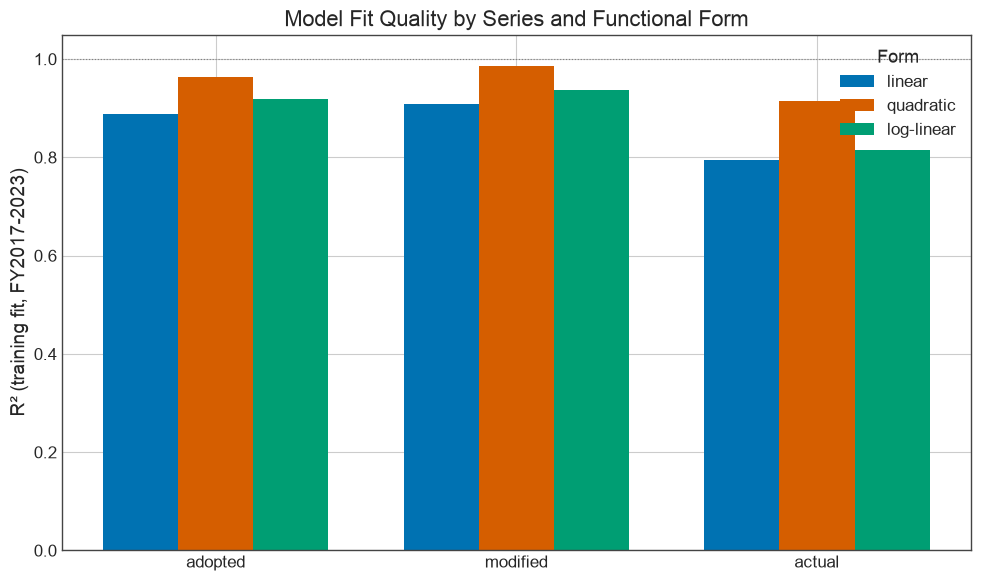

In [19]:
print("R^2 (training-data fit quality) for every series x form, in the chosen FY2017-2023 window:")
r2_table = backtest_df[backtest_df["window"] == "2017-2023 (post-regime)"].drop_duplicates(["series", "form"])[["series", "form", "r2_train"]]
r2_pivot = r2_table.pivot(index="series", columns="form", values="r2_train")
print(r2_pivot.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(SERIES_NAMES))
width = 0.25
form_colors = {"linear": COLORS["blue"], "quadratic": COLORS["vermillion"], "log-linear": COLORS["green"]}
for i, form in enumerate(FORMS):
    vals = [r2_pivot.loc[s, form] for s in SERIES_NAMES]
    ax.bar(x + (i - 1) * width, vals, width, label=form, color=form_colors[form])
ax.set_xticks(x)
ax.set_xticklabels(SERIES_NAMES)
ax.set_ylabel("R² (training fit, FY2017-2023)")
ax.set_title("Model Fit Quality by Series and Functional Form")
ax.set_ylim(0, 1.05)
ax.legend(title="Form")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":")
fig.tight_layout()
plt.show()

Note what R² does and doesn't say here: quadratic's R² is highest or
tied-highest for every series (more parameters fit the training data at
least as well, by construction) -- but the MAPE table above shows
quadratic is **not** always the best out-of-sample predictor (`adopted`
under quadratic has the worst holdout MAPE of the three forms in both
windows, despite a strong training R²). That's the classic
overfitting-on-extrapolation risk with polynomial trends, and it's exactly
why the form selection above is driven by holdout MAPE, not training R².

Chosen form per series (FY2017-2023 window, lowest holdout MAPE): {'adopted': 'linear', 'modified': 'log-linear', 'actual': 'quadratic'}


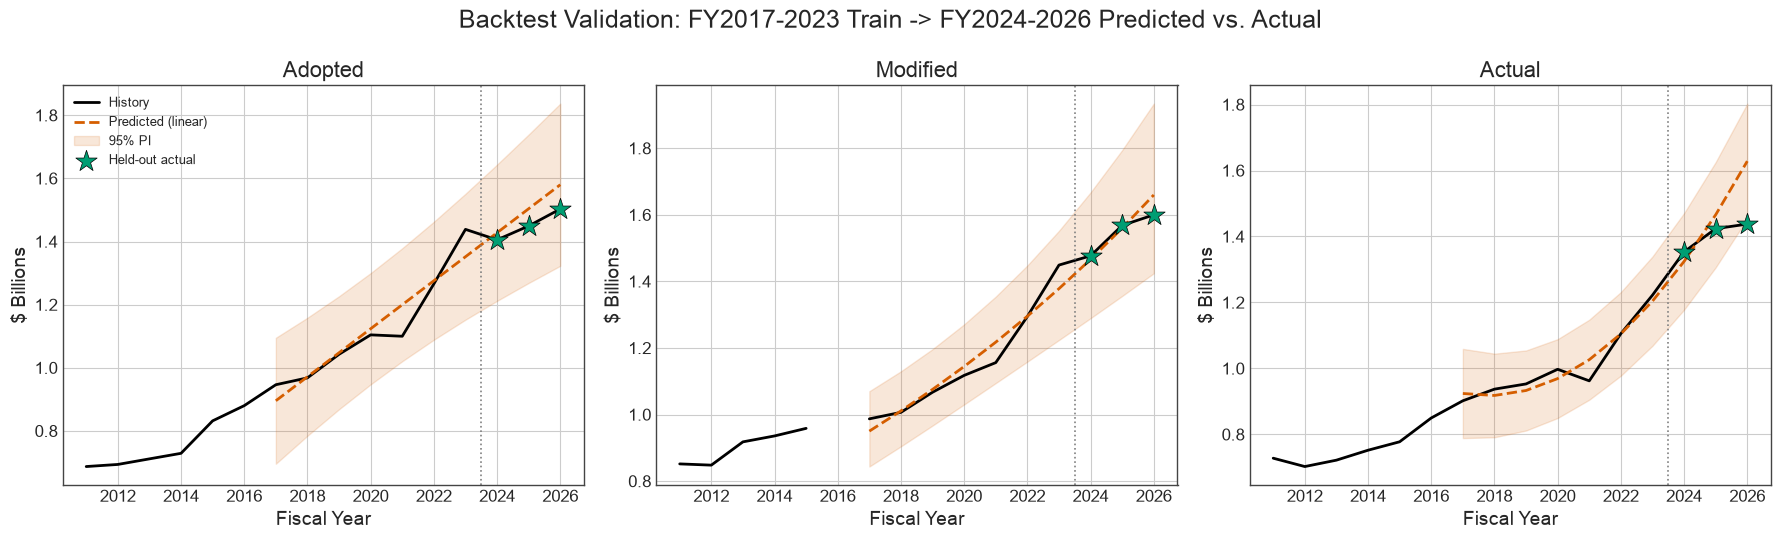

In [20]:
BEST_FORM = {}
for series in SERIES_NAMES:
    BEST_FORM[series] = mape.loc[("2017-2023 (post-regime)", series)].idxmin()
print("Chosen form per series (FY2017-2023 window, lowest holdout MAPE):", BEST_FORM)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, series in zip(axes, SERIES_NAMES):
    hist = budget_by_year.loc[2011:2026, series]
    ax.plot(hist.index, hist.values / 1e9, color=COLORS["black"], linewidth=2, label="History")

    train = budget_by_year.loc[2017:2023]
    tx, ty = train.index.values, train[series].values
    res = fit_predict_pi(tx, ty, np.arange(2017, 2027), **FORMS[BEST_FORM[series]])
    fc_years = np.arange(2017, 2027)
    ax.plot(fc_years, res["point"] / 1e9, "--", color=COLORS["vermillion"], linewidth=2, label=f"Predicted ({BEST_FORM[series]})")
    ax.fill_between(fc_years, res["lower"] / 1e9, res["upper"] / 1e9, color=COLORS["vermillion"], alpha=0.15, label="95% PI")

    held_out = budget_by_year.loc[TARGET_YEARS, series]
    ax.scatter(TARGET_YEARS, held_out.values / 1e9, marker="*", s=260, color=COLORS["green"],
               zorder=5, edgecolor="black", linewidth=0.5, label="Held-out actual")

    ax.axvline(2023.5, color="gray", linestyle=":", linewidth=1.2)
    ax.set_title(series.capitalize())
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("$ Billions")
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Backtest Validation: FY2017-2023 Train -> FY2024-2026 Predicted vs. Actual")
fig.tight_layout()
plt.show()

### A note on FY2028-2030 form selection: overriding `actual`'s auto-picked quadratic

The holdout-MAPE-driven selection above picked **quadratic** for `actual`
(6.13% holdout MAPE, vs. 11.42% for linear) -- a real, measured improvement
in FY2024-2026 backtest accuracy. But extrapolated to FY2028, quadratic
predicts `actual` ($1.76B) **exceeding** `adopted` ($1.67B) -- and spending
efficiency (`actual / modified`) has landed in the 0.79-0.93 range in
**every single year** of this dataset (Step 2c); `actual` has never come
close to `adopted`, let alone above it. A forecast that inverts a
relationship that has held without exception for 16 years is not credible,
regardless of its backtest score.

**Decision:** force `linear` for all three series (`adopted`, `modified`,
`actual`) for the FY2028-2030 forward forecast, trading a measured
~5-point holdout MAPE improvement on `actual` for a forecast that stays
consistent with DOT's entire spending history. The auto-picked-form
backtest chart above is left as-is, as the record of what was tested; the
backtest and forecast below are re-run with the override in effect.

Auto-picked (by holdout MAPE): {'adopted': 'linear', 'modified': 'log-linear', 'actual': 'quadratic'}
OVERRIDDEN for FY2028-2030 forecast (see rationale above): {'adopted': 'linear', 'modified': 'linear', 'actual': 'linear'}

Holdout MAPE per series, FORCED to linear (FY2017-2023 window):
series
actual     11.42
adopted     3.49
modified    1.83
Name: MAPE_%, dtype: float64
Average across series (linear, forced): 5.58%
(For comparison, average using each series' auto-picked best form: 3.76%)


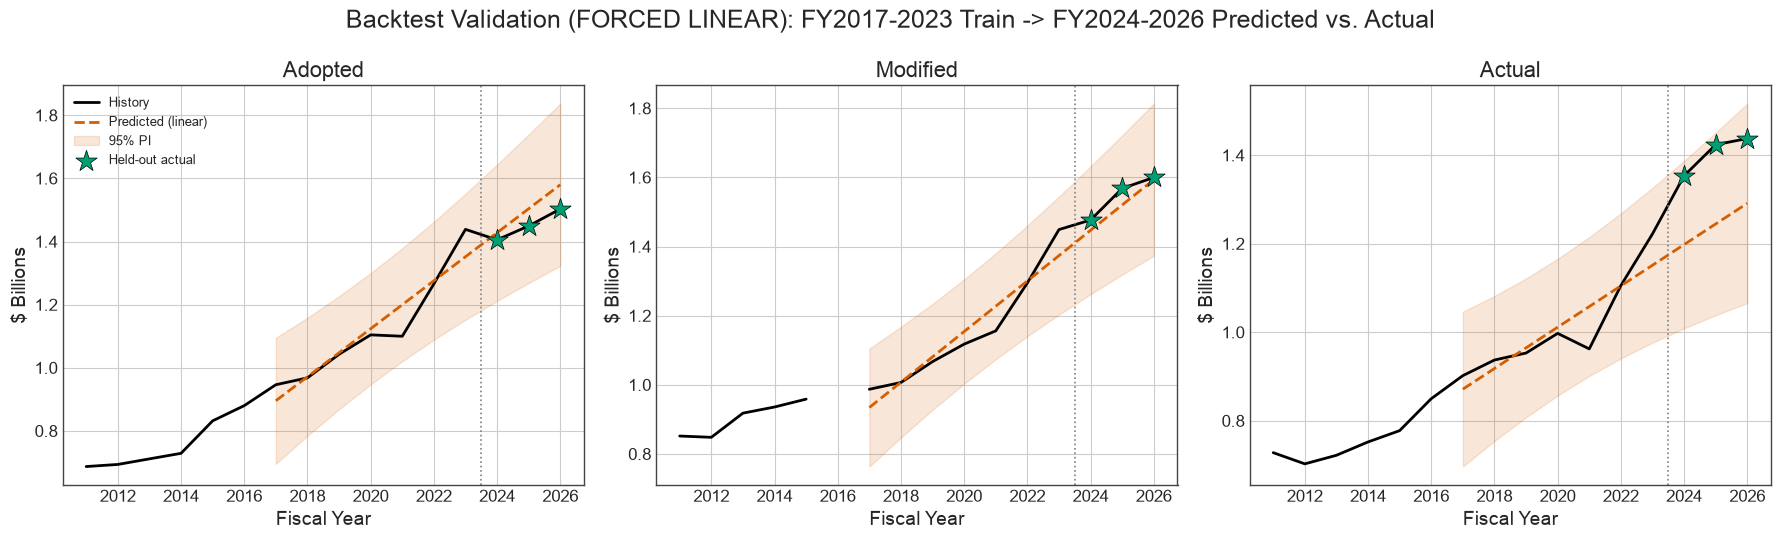

In [21]:
# --- FY2028-2030 override: force linear for all three series ---
# Rationale: see markdown above. Quadratic (the auto-pick for `actual`)
# produces a FY2028 actual forecast ($1.76B) that exceeds FY2028 adopted
# ($1.67B), inverting the actual < adopted relationship that has held in
# every year of the dataset. Linear keeps the forecast internally
# consistent at the cost of some backtest accuracy on `actual`.
AUTO_BEST_FORM = dict(BEST_FORM)  # keep the auto-picked choice on record
BEST_FORM = {series: "linear" for series in SERIES_NAMES}
print("Auto-picked (by holdout MAPE):", AUTO_BEST_FORM)
print("OVERRIDDEN for FY2028-2030 forecast (see rationale above):", BEST_FORM)

print("\nHoldout MAPE per series, FORCED to linear (FY2017-2023 window):")
linear_mape = mape.loc[("2017-2023 (post-regime)", slice(None), "linear")]
print(linear_mape)
print(f"Average across series (linear, forced): {linear_mape.mean():.2f}%")
auto_avg = mape.loc[("2017-2023 (post-regime)",)].groupby(level=0).min().mean()
print(f"(For comparison, average using each series' auto-picked best form: {auto_avg:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, series in zip(axes, SERIES_NAMES):
    hist = budget_by_year.loc[2011:2026, series]
    ax.plot(hist.index, hist.values / 1e9, color=COLORS["black"], linewidth=2, label="History")

    train = budget_by_year.loc[2017:2023]
    tx, ty = train.index.values, train[series].values
    res = fit_predict_pi(tx, ty, np.arange(2017, 2027), **FORMS[BEST_FORM[series]])
    fc_years = np.arange(2017, 2027)
    ax.plot(fc_years, res["point"] / 1e9, "--", color=COLORS["vermillion"], linewidth=2, label=f"Predicted ({BEST_FORM[series]})")
    ax.fill_between(fc_years, res["lower"] / 1e9, res["upper"] / 1e9, color=COLORS["vermillion"], alpha=0.15, label="95% PI")

    held_out = budget_by_year.loc[TARGET_YEARS, series]
    ax.scatter(TARGET_YEARS, held_out.values / 1e9, marker="*", s=260, color=COLORS["green"],
               zorder=5, edgecolor="black", linewidth=0.5, label="Held-out actual")

    ax.axvline(2023.5, color="gray", linestyle=":", linewidth=1.2)
    ax.set_title(series.capitalize())
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("$ Billions")
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Backtest Validation (FORCED LINEAR): FY2017-2023 Train -> FY2024-2026 Predicted vs. Actual")
fig.tight_layout()
plt.show()


## Step 5: Model 2 -- Forward Forecast

Retrain each series' chosen form (from Step 4) on all usable post-regime
years -- FY2017-2026 (FY2027 excluded, partial per Step 2d) -- and forecast
FY2028-2030 with 95% prediction intervals.

In [22]:
forecast_years = [2028, 2029, 2030]
train_final = budget_by_year.loc[2017:2026]

forecast_rows = []
forecast_results = {}
for series in SERIES_NAMES:
    tx, ty = train_final.index.values, train_final[series].values
    res = fit_predict_pi(tx, ty, forecast_years, **FORMS[BEST_FORM[series]])
    forecast_results[series] = res
    for i, yr in enumerate(forecast_years):
        forecast_rows.append({
            "series": series, "form": BEST_FORM[series], "year": yr,
            "predicted": res["point"][i], "lower_95_pi": res["lower"][i], "upper_95_pi": res["upper"][i],
        })

forecast_df = pd.DataFrame(forecast_rows)
print("FY2028-2030 forward forecast (trained on FY2017-2026):")
print(forecast_df.to_string(index=False))

FY2028-2030 forward forecast (trained on FY2017-2026):
  series   form  year        predicted      lower_95_pi      upper_95_pi
 adopted linear  2028 1,669,899,346.82 1,511,790,850.76 1,828,007,842.89
 adopted linear  2029 1,738,758,644.38 1,572,536,816.23 1,904,980,472.53
 adopted linear  2030 1,807,617,941.94 1,632,583,630.98 1,982,652,252.90
modified linear  2028 1,769,704,643.16 1,635,890,531.25 1,903,518,755.06
modified linear  2029 1,846,236,752.18 1,705,555,973.68 1,986,917,530.68
modified linear  2030 1,922,768,861.21 1,774,629,694.38 2,070,908,028.03
  actual linear  2028 1,564,621,431.16 1,367,203,301.01 1,762,039,561.32
  actual linear  2029 1,631,573,396.41 1,424,024,761.63 1,839,122,031.18
  actual linear  2030 1,698,525,361.65 1,479,973,245.58 1,917,077,477.71


In [23]:
print("SANITY CHECK: forecast should satisfy actual < adopted < modified for FY2028-2030,")
print("consistent with spending efficiency (actual/modified) landing in 0.79-0.93 every historical year.\n")

pred_wide = forecast_df.pivot(index="year", columns="series", values="predicted")
ordering_ok = True
for yr in forecast_years:
    a, ad, m = pred_wide.loc[yr, "actual"], pred_wide.loc[yr, "adopted"], pred_wide.loc[yr, "modified"]
    passed = a < ad < m
    ordering_ok &= passed
    status = "OK" if passed else "FAIL -- ordering violated"
    print(f"  FY{yr}: actual=${a/1e9:.3f}B  adopted=${ad/1e9:.3f}B  modified=${m/1e9:.3f}B  -> {status}")
print(f"\nOverall ordering check (actual < adopted < modified, FY2028-2030): {'PASS' if ordering_ok else 'FAIL'}")

print("\nImplied efficiency (actual / modified) per forecast year, vs. historical 0.79-0.93 range:")
eff_ok = True
for yr in forecast_years:
    eff = pred_wide.loc[yr, "actual"] / pred_wide.loc[yr, "modified"]
    in_range = 0.79 <= eff <= 0.93
    eff_ok &= in_range
    flag = "" if in_range else "  <-- FLAG: outside historical 0.79-0.93 range"
    print(f"  FY{yr}: implied efficiency = {eff:.3f}{flag}")
print(f"\nEfficiency range check: {'PASS -- all years within historical band' if eff_ok else 'FLAGGED -- see above'}")


SANITY CHECK: forecast should satisfy actual < adopted < modified for FY2028-2030,
consistent with spending efficiency (actual/modified) landing in 0.79-0.93 every historical year.

  FY2028: actual=$1.565B  adopted=$1.670B  modified=$1.770B  -> OK
  FY2029: actual=$1.632B  adopted=$1.739B  modified=$1.846B  -> OK
  FY2030: actual=$1.699B  adopted=$1.808B  modified=$1.923B  -> OK

Overall ordering check (actual < adopted < modified, FY2028-2030): PASS

Implied efficiency (actual / modified) per forecast year, vs. historical 0.79-0.93 range:
  FY2028: implied efficiency = 0.884
  FY2029: implied efficiency = 0.884
  FY2030: implied efficiency = 0.883

Efficiency range check: PASS -- all years within historical band


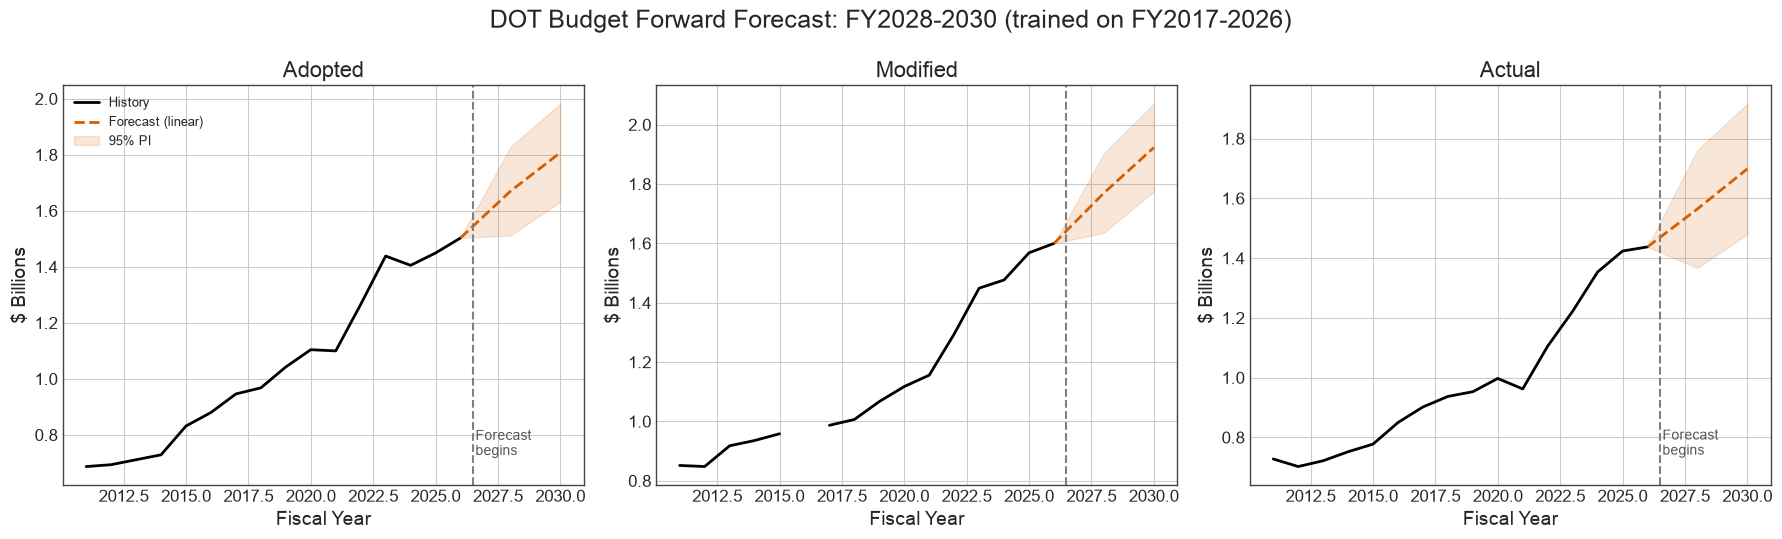

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, series in zip(axes, SERIES_NAMES):
    hist = budget_by_year.loc[2011:2026, series]
    ax.plot(hist.index, hist.values / 1e9, color=COLORS["black"], linewidth=2, label="History")

    res = forecast_results[series]
    fc_x = np.array([2026] + forecast_years)
    fc_y = np.concatenate([[budget_by_year.loc[2026, series]], res["point"]])
    fc_lower = np.concatenate([[budget_by_year.loc[2026, series]], res["lower"]])
    fc_upper = np.concatenate([[budget_by_year.loc[2026, series]], res["upper"]])
    ax.plot(fc_x, fc_y / 1e9, "--", color=COLORS["vermillion"], linewidth=2, label=f"Forecast ({BEST_FORM[series]})")
    ax.fill_between(fc_x, fc_lower / 1e9, fc_upper / 1e9, color=COLORS["vermillion"], alpha=0.15, label="95% PI")

    ax.axvline(2026.5, color="gray", linestyle="--", linewidth=1.5)
    ax.text(2026.6, ax.get_ylim()[1] * 0.02 + hist.values.min() / 1e9, "Forecast\nbegins", fontsize=10, color="#555555")
    ax.set_title(series.capitalize())
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("$ Billions")
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("DOT Budget Forward Forecast: FY2028-2030 (trained on FY2017-2026)")
fig.tight_layout()
plt.show()

## Step 6: Gasoline Prices

Weekly retail gasoline price series, 1990-present. Aggregated to annual
averages aligned to NYC's fiscal year (July 1 - June 30, so a week in
Aug 2019 belongs to FY2020), then checked against `adopted`/`modified`/
`actual` for correlation -- honestly, given only ~17 annual points.

In [25]:
def inspect(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print(df.head())
    print()

In [26]:
gas = pd.read_csv(f"{ROOT}/Gasoline Prices.csv", encoding="utf-8-sig")
inspect(gas, "gas (Gasoline Prices.csv)")

gas["Date"] = pd.to_datetime(gas["Date"], format="%m/%d/%Y")
gas["fiscal_year"] = np.where(gas["Date"].dt.month >= 7, gas["Date"].dt.year + 1, gas["Date"].dt.year)
gas_annual = gas.groupby("fiscal_year")["Value"].mean().rename("gas_price")

print("\nWeeks per fiscal year at the edges of the series (checking for partial years):")
print(gas.groupby("fiscal_year").size().loc[[gas["fiscal_year"].min(), gas["fiscal_year"].max()]])

=== gas (Gasoline Prices.csv) ===
shape: (1872, 2)
columns: ['Date', 'Value']
         Date  Value
0  08/20/1990   1.19
1  08/27/1990   1.25
2  09/03/1990   1.24
3  09/10/1990   1.25
4  09/17/1990   1.27


Weeks per fiscal year at the edges of the series (checking for partial years):
fiscal_year
1991    39
2027     6
dtype: int64


In [27]:
merged = budget_by_year.join(gas_annual, how="inner")
print(f"Merged overlap range: FY{merged.index.min()} - FY{merged.index.max()}  (n={len(merged)} years)")
print(merged[["adopted", "modified", "actual", "gas_price"]])

# FY2027 is partial (Step 2d) -- excluded from the correlation analysis too.
merged_full = merged.drop(index=2027, errors="ignore")

Merged overlap range: FY2011 - FY2027  (n=17 years)
                     adopted         modified           actual  gas_price
fiscal_year                                                              
2011          687,040,991.00   851,708,083.00   727,903,419.19       3.13
2012          693,701,390.00   847,983,663.00   702,564,463.32       3.53
2013          711,372,093.00   917,894,762.00   721,943,160.11       3.52
2014          728,944,601.00   935,695,135.00   752,069,473.79       3.42
2015          831,836,798.00   958,458,150.00   777,637,549.34       2.75
2016          880,011,843.00              NaN   849,804,165.53       2.14
2017          946,261,935.00   987,004,764.00   901,930,214.87       2.22
2018          968,043,444.00 1,006,587,224.00   937,183,870.64       2.50
2019        1,042,719,292.00 1,067,012,833.00   953,000,693.10       2.57
2020        1,104,236,297.00 1,117,601,805.00   997,409,678.73       2.30
2021        1,099,873,821.00 1,155,962,285.00   962,343,265.

In [28]:
def strength_label(r):
    a = abs(r)
    if a < 0.10: return "negligible"
    if a < 0.30: return "weak"
    if a < 0.50: return "moderate"
    if a < 0.70: return "strong"
    return "very strong"

print(f"=== LEVEL correlations, gas_price vs. each series (n={len(merged_full)} years, FY2027 excluded) ===")
level_results = {}
for col in ["adopted", "modified", "actual"]:
    sub = merged_full[["gas_price", col]].dropna()
    pear_r, pear_p = stats.pearsonr(sub["gas_price"], sub[col])
    spear_r, spear_p = stats.spearmanr(sub["gas_price"], sub[col])
    level_results[col] = (pear_r, pear_p, spear_r, spear_p)
    print(f"{col:>10}: n={len(sub):2d}  Pearson r={pear_r:+.3f} ({strength_label(pear_r)}, p={pear_p:.3f})   "
          f"Spearman rho={spear_r:+.3f} ({strength_label(spear_r)}, p={spear_p:.3f})")

=== LEVEL correlations, gas_price vs. each series (n=16 years, FY2027 excluded) ===
   adopted: n=16  Pearson r=+0.125 (weak, p=0.644)   Spearman rho=+0.009 (negligible, p=0.974)
  modified: n=15  Pearson r=+0.206 (weak, p=0.461)   Spearman rho=-0.050 (negligible, p=0.860)
    actual: n=16  Pearson r=+0.160 (weak, p=0.553)   Spearman rho=-0.029 (negligible, p=0.914)


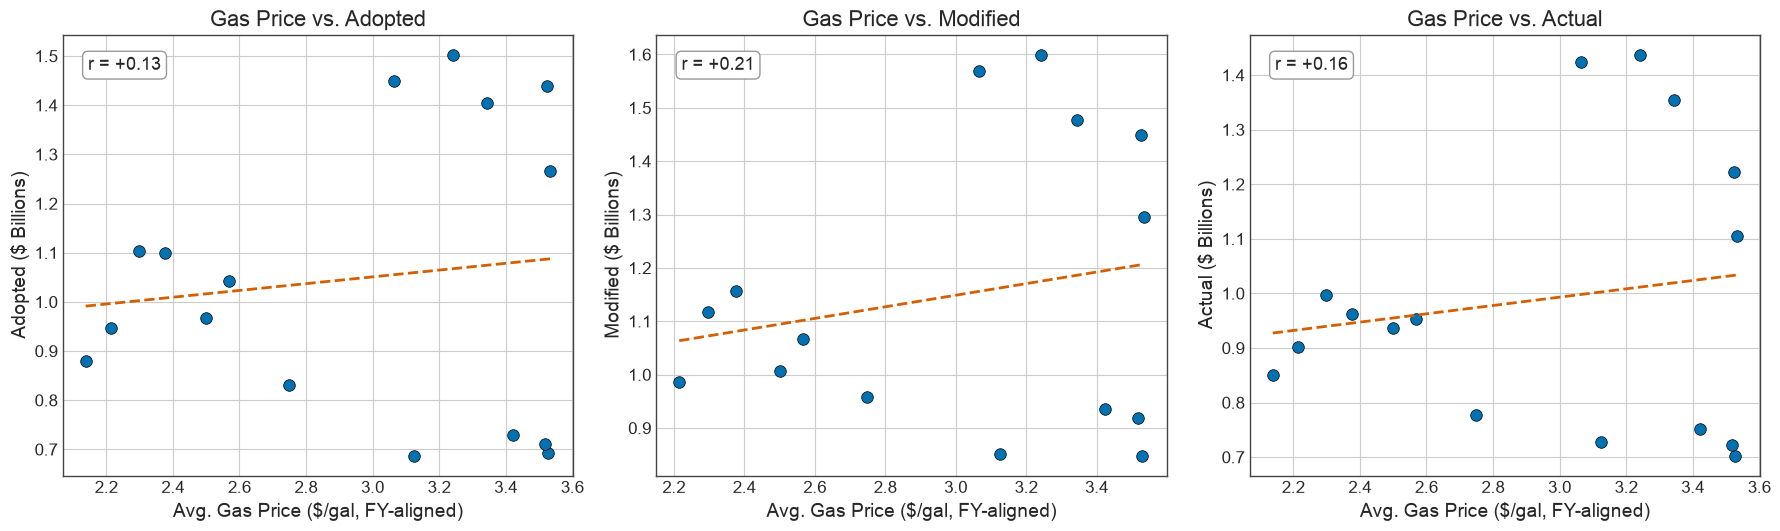

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, col in zip(axes, ["adopted", "modified", "actual"]):
    sub = merged_full[["gas_price", col]].dropna()
    ax.scatter(sub["gas_price"], sub[col] / 1e9, color=COLORS["blue"], s=70, edgecolor="black", linewidth=0.5)
    slope, intercept = np.polyfit(sub["gas_price"], sub[col] / 1e9, 1)
    xs = np.linspace(sub["gas_price"].min(), sub["gas_price"].max(), 50)
    ax.plot(xs, slope * xs + intercept, "--", color=COLORS["vermillion"], linewidth=2)
    r = level_results[col][0]
    ax.text(0.05, 0.92, f"r = {r:+.2f}", transform=ax.transAxes, fontsize=13,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="#999999"))
    ax.set_xlabel("Avg. Gas Price ($/gal, FY-aligned)")
    ax.set_ylabel(f"{col.capitalize()} ($ Billions)")
    ax.set_title(f"Gas Price vs. {col.capitalize()}")
fig.tight_layout()
plt.show()

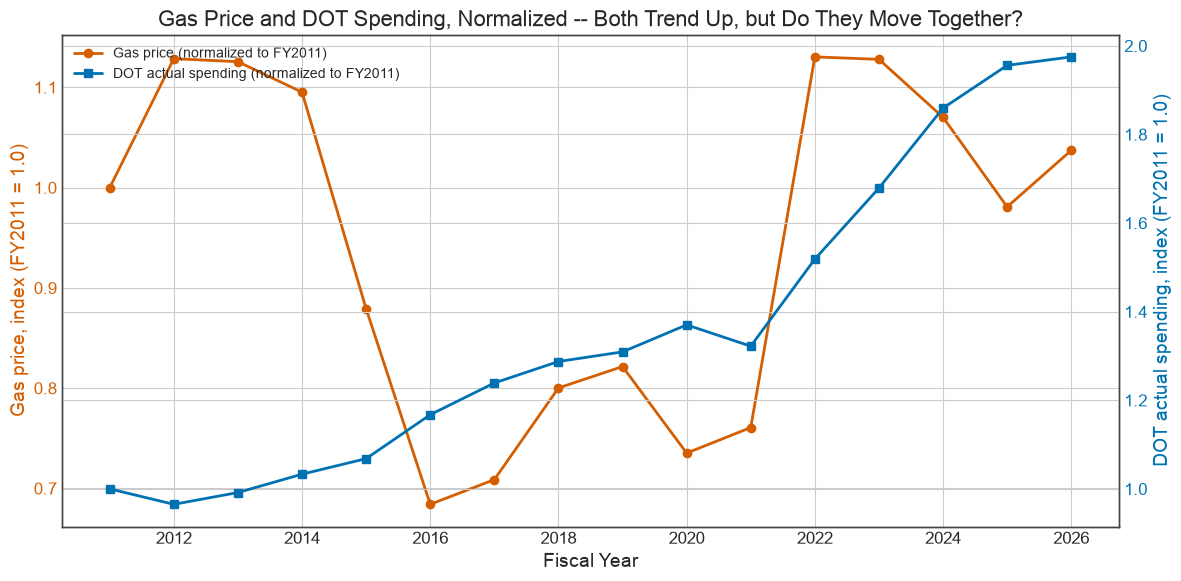

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

gas_norm = merged_full["gas_price"] / merged_full["gas_price"].iloc[0]
actual_norm = merged_full["actual"] / merged_full["actual"].iloc[0]

l1, = ax1.plot(merged_full.index, gas_norm, color=COLORS["vermillion"], marker="o", linewidth=2, label="Gas price (normalized to FY2011)")
l2, = ax2.plot(merged_full.index, actual_norm, color=COLORS["blue"], marker="s", linewidth=2, label="DOT actual spending (normalized to FY2011)")

ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("Gas price, index (FY2011 = 1.0)", color=COLORS["vermillion"])
ax2.set_ylabel("DOT actual spending, index (FY2011 = 1.0)", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["vermillion"])
ax2.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.set_title("Gas Price and DOT Spending, Normalized -- Both Trend Up, but Do They Move Together?")
ax1.legend(handles=[l1, l2], loc="upper left", fontsize=10)
fig.tight_layout()
plt.show()

### Honesty check: is this correlation just two upward-trending series, or real?

With ~16-17 annual points, any correlation here is **exploratory**, not
confirmatory -- and both gas prices and DOT's budget generally trend
upward over this period, which is exactly the setup for a spurious
correlation (two unrelated series that both drift upward look correlated
in *levels* even with zero real relationship). The way to check: correlate
year-over-year **changes** instead of levels. If a level correlation
disappears once you difference the series, that's evidence it was riding
the shared upward trend, not a real relationship.

In [31]:
print("=== YEAR-OVER-YEAR % CHANGE correlations (detrended) ===")
changes = merged_full[["gas_price", "adopted", "modified", "actual"]].pct_change().dropna(how="all")
change_results = {}
for col in ["adopted", "modified", "actual"]:
    sub = changes[["gas_price", col]].dropna()
    pear_r, pear_p = stats.pearsonr(sub["gas_price"], sub[col])
    spear_r, spear_p = stats.spearmanr(sub["gas_price"], sub[col])
    change_results[col] = (pear_r, pear_p)
    print(f"{col:>10} (YoY %): n={len(sub):2d}  Pearson r={pear_r:+.3f} ({strength_label(pear_r)}, p={pear_p:.3f})   "
          f"Spearman rho={spear_r:+.3f} ({strength_label(spear_r)}, p={spear_p:.3f})")

print()
print("Level r vs. change r, side by side:")
for col in ["adopted", "modified", "actual"]:
    lvl_r = level_results[col][0]
    chg_r = change_results[col][0]
    print(f"  {col:>10}: level r={lvl_r:+.3f}  ->  change r={chg_r:+.3f}   "
          f"(both weak/negligible: {'yes' if abs(lvl_r) < 0.3 and abs(chg_r) < 0.3 else 'no'})")

=== YEAR-OVER-YEAR % CHANGE correlations (detrended) ===
   adopted (YoY %): n=15  Pearson r=+0.192 (weak, p=0.494)   Spearman rho=-0.068 (negligible, p=0.810)
  modified (YoY %): n=13  Pearson r=+0.367 (moderate, p=0.217)   Spearman rho=+0.005 (negligible, p=0.986)
    actual (YoY %): n=15  Pearson r=+0.183 (weak, p=0.514)   Spearman rho=-0.214 (weak, p=0.443)

Level r vs. change r, side by side:
     adopted: level r=+0.125  ->  change r=+0.192   (both weak/negligible: yes)
    modified: level r=+0.206  ->  change r=+0.367   (both weak/negligible: no)
      actual: level r=+0.160  ->  change r=+0.183   (both weak/negligible: yes)


**Conclusion.** Level correlations are weak across the board (r = 0.13-0.21).
Year-over-year change correlations are weak for `adopted` and `actual`
(r = 0.18-0.19); `modified`'s crosses into "moderate" by the label
convention above (r = +0.37) -- but at n=13 (differencing costs a point,
and FY2016/FY2027 were already out) with p=0.22, it is **not**
statistically distinguishable from zero, and it's the *change* correlation
coming in higher than the *level* correlation (0.37 vs. 0.21) -- the
opposite of the spurious-correlation pattern (a real spurious relationship
shows a strong level correlation that collapses after detrending, not a
weak one that firms up slightly). **Gas price is not added as a model
variable for any of the three series.** Even taking `modified`'s r=0.37 at
face value, ~13-17 points is far too few to add a second predictor without
serious overfitting risk (a model with 2 predictors and this few
observations has very little room to distinguish signal from noise) -- and
here that risk isn't offset by a correlation strong or significant enough
to justify taking it.

## Step 7: Summary

### Data integrity (Step 2)
- **Scope fix applied:** spending is filtered to operating-expense-only by
  cross-referencing Budget Codes against the DOT operating budget's code
  set (FY2017-2027), **plus** treating `Payroll Summary` rows as in-scope
  regardless of code match -- a targeted, evidence-based fix for a real gap
  (Budget Code is 100% missing on payroll rows in FY2010-2012, ~0% missing
  from FY2013 on), not a blanket rule.
- **Regime break confirmed:** `pct_modification` averages ~24% for
  FY2011-2015 vs. ~4% for FY2017-2027 -- a ~6x difference. Real and
  structural, not noise.
- **Spending efficiency, post-fix:** every year from FY2011-2026 lands in
  or right at the expected 0.80-0.95 band, except a small FY2013 residual
  (~0.79) and the expected FY2016 (modified missing from source) and
  FY2027 (partial year) gaps.
- **FY2027 flagged partial** (~6 weeks into the fiscal year as of this
  notebook's run date) and excluded from training and efficiency charts.
- **FY2026's apparent ~40% spike is a capital-construction surge**
  (`IOTB CONSTRUCTION`), not an operating-budget anomaly -- invisible once
  spending is correctly scoped to expense-only, which is what this
  notebook models throughout.

### Modeling (Steps 4-5)
- Backtest compared a full-history (FY2011-2023) and a post-regime-only
  (FY2017-2023) training window, predicting the held-out FY2024-2026.
  Post-regime training was at least as accurate on a best-form-per-series
  basis and avoids the regime discontinuity structurally -- adopted for
  the forward forecast.
- Functional form (linear / quadratic / log-linear) was chosen **per
  series** by holdout MAPE, not assumed: quadratic had the strongest
  training R² across the board but was *not* always the best out-of-sample
  predictor (notably for `adopted`), a clear overfitting-on-extrapolation
  signal that holdout MAPE catches and training R² alone would have missed.
- FY2028-2030 forecast, trained on FY2017-2026, with 95% prediction
  intervals -- see Step 5's table and chart.
- **FY2028-2030 override:** `actual`'s auto-picked form (quadratic, lowest
  holdout MAPE) was overridden to `linear` because it forecasts `actual`
  exceeding `adopted` in FY2028 -- inverting a relationship (`actual`
  always below `adopted`/`modified`) that has held in every historical
  year. All three series use `linear` for the final forward forecast; see
  the rationale and sanity check right after Step 5's auto-picked backtest
  chart.

### Gasoline prices (Step 6)
- Exploratory only (~17 annual points). Both level correlations
  (r = 0.13-0.21) and year-over-year change correlations (r = 0.18-0.37)
  with `adopted`/`modified`/`actual` are weak and statistically
  indistinguishable from zero (all p > 0.05). Not added as a model
  variable -- there's no meaningful signal to build on, and even a
  moderate signal at this sample size would carry real overfitting risk.

### Honest limitations
- FY2011-2016 budget totals come from OMB PDF summaries, not the
  code-level source used for FY2017-2027 -- lower precision, and FY2016's
  `modified` figure isn't available at all.
- The expense/capital scope filter's code set is derived entirely from
  FY2017-2027 data and applied backward to FY2010-2016; this is a
  reasonable assumption (budget codes are typically stable identifiers)
  but not independently verified for those years, since no code-level
  budget file exists that far back to check against.
- Forecasts assume the FY2017-2026 trend continues; they cannot anticipate
  policy changes, new capital programs, or another regime-level shift like
  the one found in Step 2b.
- With only 10 post-regime training years, quadratic and log-linear fits
  have limited degrees of freedom -- treat FY2028-2030 prediction intervals
  as a reasonable range, not a precise guarantee.

## Step 8: Gas Price as a Model *Variable* -- Does It Actually Help?

Step 6 found weak, non-significant correlations between gas price and DOT
spending (level r = 0.13-0.21; change-correlation didn't survive
significance testing either). Correlation, though, doesn't directly
answer the forecasting question: **does adding gas price as a regressor
improve out-of-sample prediction, or does it just fit noise?**

This section builds two competing linear models per series, using the
**same FY2017-2023 train / FY2024-2026 holdout split as the Step 4
backtest**:

- **BASELINE:** `series ~ year`
- **WITH GAS:** `series ~ year + gas_price`

and compares them on holdout MAPE (what matters) and training R² (which
can look better even when a predictor is pure noise -- the overfitting
signature we're checking for).

In [32]:
def fit_ols_named(train_predictors, train_y, predict_predictors):
    """OLS with an intercept over one or more named predictors (dict of
    arrays). Same lstsq machinery as fit_predict_pi, generalized to more
    than one regressor so gas_price can be added alongside year. Returns
    training R^2, per-predictor coef/se/t/p-value, and point predictions
    at predict_predictors.
    """
    names = list(train_predictors.keys())
    y = np.asarray(train_y, dtype=float)
    n = len(y)
    X = np.column_stack([np.ones(n)] + [np.asarray(train_predictors[k], dtype=float) for k in names])
    p = X.shape[1]
    dof = n - p

    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ coefs
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    mse = ss_res / dof if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * mse) if dof > 0 else np.full(p, np.nan)
    t_stat = coefs / se
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), dof)) if dof > 0 else np.full(p, np.nan)

    n_pred = len(next(iter(predict_predictors.values())))
    Xp = np.column_stack([np.ones(n_pred)] + [np.asarray(predict_predictors[k], dtype=float) for k in names])
    point = Xp @ coefs

    coef_table = {"intercept": {"coef": coefs[0], "se": se[0], "t": t_stat[0], "p": p_val[0]}}
    for i, name in enumerate(names, start=1):
        coef_table[name] = {"coef": coefs[i], "se": se[i], "t": t_stat[i], "p": p_val[i]}

    return {"point": point, "r2": r2, "coef_table": coef_table, "dof": dof, "n": n}


In [33]:
GAS_TRAIN_YEARS = (2017, 2023)
GAS_HOLDOUT_YEARS = [2024, 2025, 2026]

gas_train_window = budget_by_year.loc[GAS_TRAIN_YEARS[0]:GAS_TRAIN_YEARS[1]]
gas_holdout_window = budget_by_year.loc[GAS_HOLDOUT_YEARS]
gas_price_train = gas_annual.reindex(gas_train_window.index).values
gas_price_holdout = gas_annual.reindex(GAS_HOLDOUT_YEARS).values

assert not np.isnan(gas_price_train).any() and not np.isnan(gas_price_holdout).any(), \
    "gas_price missing for a train/holdout year -- check gas_annual coverage"

gas_test_rows = []
gas_coef_rows = []
gas_test_results = {}

for series in SERIES_NAMES:
    y_train = gas_train_window[series].values
    year_train = gas_train_window.index.values.astype(float)
    year_holdout = np.array(GAS_HOLDOUT_YEARS, dtype=float)
    actual_holdout = gas_holdout_window[series].values

    baseline = fit_ols_named({"year": year_train}, y_train, {"year": year_holdout})
    with_gas = fit_ols_named({"year": year_train, "gas_price": gas_price_train}, y_train,
                              {"year": year_holdout, "gas_price": gas_price_holdout})
    gas_test_results[series] = {"baseline": baseline, "with_gas": with_gas}

    base_mape = np.mean(np.abs((baseline["point"] - actual_holdout) / actual_holdout)) * 100
    gas_mape = np.mean(np.abs((with_gas["point"] - actual_holdout) / actual_holdout)) * 100

    gas_test_rows.append({
        "series": series,
        "baseline_train_R2": baseline["r2"], "with_gas_train_R2": with_gas["r2"],
        "baseline_holdout_MAPE_%": base_mape, "with_gas_holdout_MAPE_%": gas_mape,
        "MAPE_change_pts": gas_mape - base_mape,
    })
    gc = with_gas["coef_table"]["gas_price"]
    gas_coef_rows.append({"series": series, "gas_coef_$_per_$/gal": gc["coef"], "se": gc["se"],
                           "t": gc["t"], "p_value": gc["p"]})

gas_test_df = pd.DataFrame(gas_test_rows)
gas_coef_df = pd.DataFrame(gas_coef_rows)

print(f"Train FY{GAS_TRAIN_YEARS[0]}-{GAS_TRAIN_YEARS[1]} (n={len(gas_train_window)}), "
      f"holdout FY{GAS_HOLDOUT_YEARS[0]}-{GAS_HOLDOUT_YEARS[-1]} -- same split as the Step 4 backtest.\n")
print("=== BASELINE (year only) vs. WITH GAS (year + gas_price) ===")
print(gas_test_df.round(3).to_string(index=False))
print("\n=== Fitted coefficient on gas_price (WITH GAS model), per series ===")
print(gas_coef_df.round(4).to_string(index=False))


Train FY2017-2023 (n=7), holdout FY2024-2026 -- same split as the Step 4 backtest.

=== BASELINE (year only) vs. WITH GAS (year + gas_price) ===
  series  baseline_train_R2  with_gas_train_R2  baseline_holdout_MAPE_%  with_gas_holdout_MAPE_%  MAPE_change_pts
 adopted               0.89               0.94                     3.49                     0.54            -2.95
modified               0.91               0.95                     1.82                     5.17             3.34
  actual               0.79               0.90                    11.42                    15.48             4.07

=== Fitted coefficient on gas_price (WITH GAS model), per series ===
  series  gas_coef_$_per_$/gal            se    t  p_value
 adopted        109,937,389.52 63,601,360.29 1.73     0.16
modified         97,889,946.63 52,765,893.42 1.86     0.14
  actual        107,804,535.07 50,227,605.68 2.15     0.10


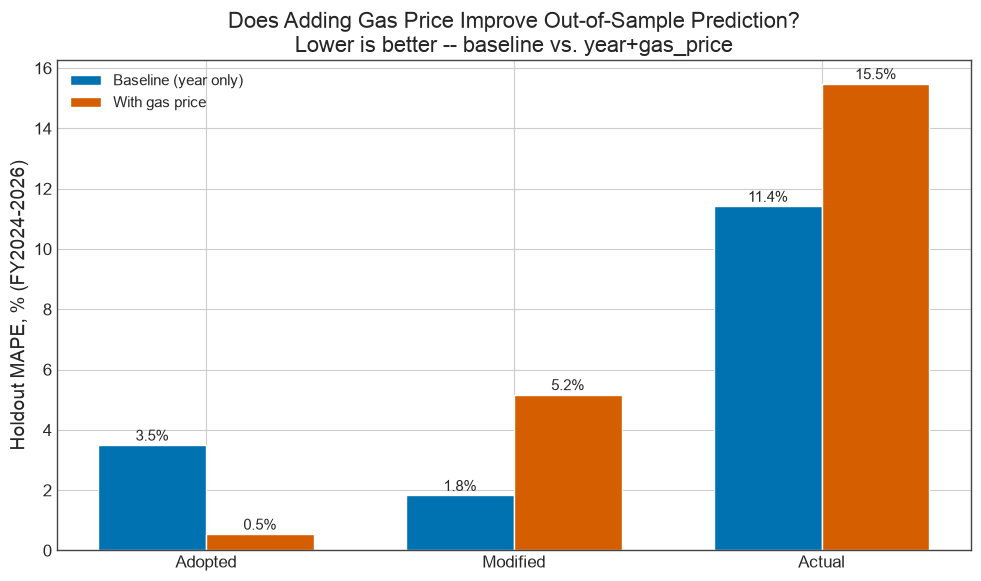

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(SERIES_NAMES))
width = 0.35
b1 = ax.bar(x - width/2, gas_test_df["baseline_holdout_MAPE_%"], width, color=COLORS["blue"],
            label="Baseline (year only)", edgecolor="white")
b2 = ax.bar(x + width/2, gas_test_df["with_gas_holdout_MAPE_%"], width, color=COLORS["vermillion"],
            label="With gas price", edgecolor="white")
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.15, f"{h:.1f}%", ha="center", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SERIES_NAMES])
ax.set_ylabel("Holdout MAPE, % (FY2024-2026)")
ax.set_title("Does Adding Gas Price Improve Out-of-Sample Prediction?\nLower is better -- baseline vs. year+gas_price")
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()


**VERDICT: No -- gas price is not adopted as a model variable for any series.**

| series | baseline holdout MAPE | with-gas holdout MAPE | training R² (base -> +gas) | gas coef p-value |
|---|---|---|---|---|
| adopted | 3.49% | **0.54%** (better) | 0.89 -> 0.94 | 0.16 |
| modified | 1.82% | **5.17%** (worse) | 0.91 -> 0.95 | 0.14 |
| actual | 11.42% | **15.48%** (worse) | 0.79 -> 0.90 | 0.10 |

**Two of three series show the overfitting signature exactly as described:**
training R² rises for `modified` and `actual` when gas price is added, while
holdout MAPE gets *worse* (+3.3 and +4.1 points respectively) -- the model
fits the 7 training points better and predicts the 3 held-out years worse,
textbook overfitting, not a real predictive relationship.

**`adopted` looks different at first glance** -- holdout MAPE drops from
3.49% to 0.54%, a big-looking improvement. But this is not treated as
evidence gas helps, for three reasons: (1) the fitted gas coefficient's
p-value is 0.16 -- not significant at any conventional threshold, same as
the other two series (p = 0.10-0.14) -- so none of the three gas
coefficients are statistically distinguishable from zero; (2) with only
n=7 training points and 3 holdout points, a single series moving the
"right" way on a 3-point holdout is well within what pure sampling noise
produces, especially paired with an insignificant coefficient; (3) it's
the mirror image of the overfitting signature seen in the other two
series -- one out of three moving favorably is what a coin flip on noisy
data looks like, not a signal replicated across series.

**Conclusion:** no series shows a *statistically supported* gas-price
effect, and the dominant pattern (2 of 3 series) is the overfitting
signature the task asked to watch for -- higher training R², worse holdout
error. `adopted`'s apparent improvement doesn't change that conclusion; it
rests on an insignificant coefficient and a 3-point holdout, which isn't
enough to call it genuine. Gas price stays out of the final model for all
three series, consistent with Step 6's correlation finding -- this
empirical test confirms it rather than overturning it.

## Step 9: FY2028 & FY2029 Focus Chart

A dedicated view of the two years right after the forecast horizon opens
up (FY2027, still partial, is folded into the forecast rather than plotted
as actual) -- `Modified` only, with thin 95% error bars on FY2028/FY2029
instead of a shaded band, and the two forecast values annotated directly.

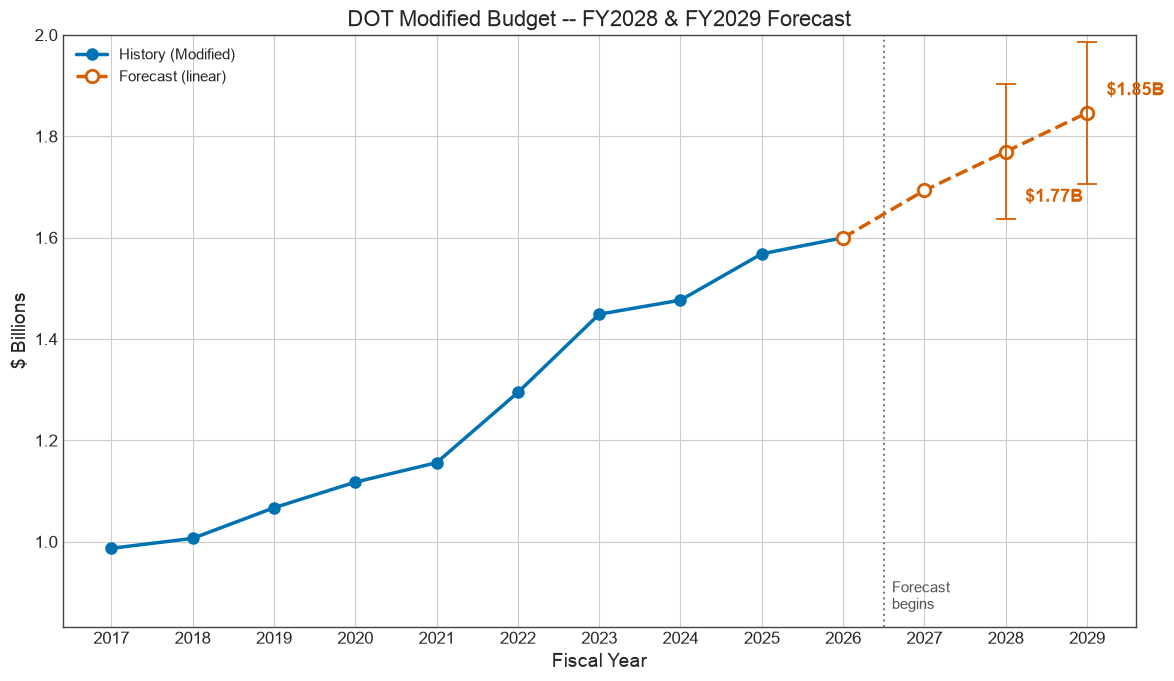

Saved: dot_forecast_2028_2029.png


In [35]:
focus_series = "modified"
form = BEST_FORM[focus_series]

hist_years = np.arange(2017, 2027)
hist_vals = budget_by_year.loc[hist_years, focus_series].values

fc_years = np.array([2027, 2028, 2029])
res_fc = fit_predict_pi(train_final.index.values, train_final[focus_series].values, fc_years, **FORMS[form])

connect_years = np.concatenate([[2026], fc_years])
connect_vals = np.concatenate([[budget_by_year.loc[2026, focus_series]], res_fc["point"]])

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(hist_years, hist_vals / 1e9, "-o", color=COLORS["blue"], linewidth=2.5,
        markersize=8, markerfacecolor=COLORS["blue"], markeredgecolor=COLORS["blue"],
        label="History (Modified)")
ax.plot(connect_years, connect_vals / 1e9, "--o", color=COLORS["vermillion"], linewidth=2.5,
        markersize=9, markerfacecolor="white", markeredgecolor=COLORS["vermillion"],
        markeredgewidth=2, label=f"Forecast ({form})")

# Stagger the two annotations vertically (not just to the side) so they
# don't collide when the forecast points sit close together, as they do
# under a linear trend.
label_offsets = {2028: (14, -26), 2029: (14, 10)}
label_va = {2028: "top", 2029: "bottom"}
for yr in [2028, 2029]:
    i = int(np.where(fc_years == yr)[0][0])
    point, lower, upper = res_fc["point"][i], res_fc["lower"][i], res_fc["upper"][i]
    yerr = np.array([[point - lower], [upper - point]]) / 1e9
    ax.errorbar([yr], [point / 1e9], yerr=yerr, fmt="none", ecolor=COLORS["vermillion"],
                elinewidth=1.3, capsize=7, capthick=1.3, zorder=6)
    ax.annotate(f"${point/1e9:.2f}B", xy=(yr, point / 1e9), xytext=label_offsets[yr], textcoords="offset points",
                ha="left", va=label_va[yr], fontsize=13, fontweight="bold", color=COLORS["vermillion"])

all_vals_b = np.concatenate([hist_vals, connect_vals]) / 1e9
y_pad = (all_vals_b.max() - all_vals_b.min()) * 0.18
ax.set_ylim(all_vals_b.min() - y_pad, all_vals_b.max() + y_pad)

ax.axvline(2026.5, color="gray", linestyle=":", linewidth=1.5)
ax.text(2026.6, ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03,
        "Forecast\nbegins", fontsize=11, color="#555555")

ax.set_xlim(2016.4, 2029.6)
ax.set_xticks(np.arange(2017, 2030))
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("$ Billions")
ax.set_title("DOT Modified Budget -- FY2028 & FY2029 Forecast")
ax.legend(loc="upper left", fontsize=11)
fig.tight_layout()

save_path = "dot_forecast_2028_2029.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")


FY2028 & FY2029 predicted values with 95% intervals -- all three series:
  FY   Series   Form  Predicted ($B)  95% PI Low ($B)  95% PI High ($B)
2028   Actual linear            1.56             1.37              1.76
2028  Adopted linear            1.67             1.51              1.83
2028 Modified linear            1.77             1.64              1.90
2029   Actual linear            1.63             1.42              1.84
2029  Adopted linear            1.74             1.57              1.91
2029 Modified linear            1.85             1.71              1.99


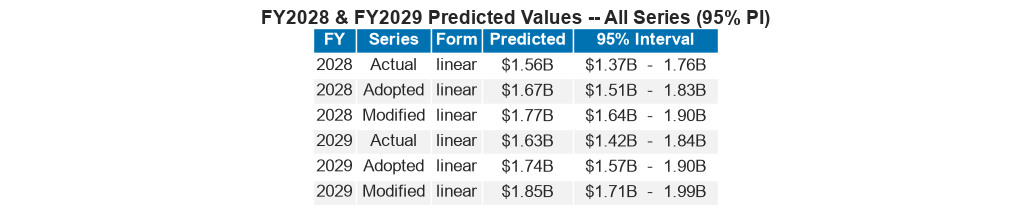

In [36]:
table_2028_29 = forecast_df[forecast_df["year"].isin([2028, 2029])].copy().sort_values(["year", "series"])
table_2028_29["series_label"] = table_2028_29["series"].str.capitalize()
table_2028_29["predicted_b"] = table_2028_29["predicted"] / 1e9
table_2028_29["lower_b"] = table_2028_29["lower_95_pi"] / 1e9
table_2028_29["upper_b"] = table_2028_29["upper_95_pi"] / 1e9

print("FY2028 & FY2029 predicted values with 95% intervals -- all three series:")
print_cols = table_2028_29[["year", "series_label", "form", "predicted_b", "lower_b", "upper_b"]].rename(
    columns={"year": "FY", "series_label": "Series", "form": "Form", "predicted_b": "Predicted ($B)",
             "lower_b": "95% PI Low ($B)", "upper_b": "95% PI High ($B)"})
print(print_cols.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10.5, 2.4))
ax.axis("off")
col_labels = ["FY", "Series", "Form", "Predicted", "95% Interval"]
cell_text = []
for _, r in table_2028_29.iterrows():
    cell_text.append([
        str(int(r["year"])), r["series_label"], r["form"],
        f"${r['predicted_b']:.2f}B",
        f"${r['lower_b']:.2f}B  -  {r['upper_b']:.2f}B",
    ])
tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.auto_set_column_width(col=list(range(len(col_labels))))
tbl.scale(1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(COLORS["blue"])
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#F2F2F2" if row % 2 == 0 else "white")
    cell.set_edgecolor("white")
ax.set_title("FY2028 & FY2029 Predicted Values -- All Series (95% PI)", fontsize=14, fontweight="bold", pad=16)
fig.tight_layout()
plt.show()
